In [1]:
import time
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import heapq
from memory_profiler import memory_usage
%load_ext memory_profiler

# --- 1. Input Modeling ---

# Graph represented as an adjacency matrix (Distances between locations)
graph_matrix = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]
num_locations = len(graph_matrix)

# Parcel metadata: (id, value, weight)
parcels = [('P1', 60, 10), ('P2', 100, 20), ('P3', 120, 30)]
vehicle_capacity = 50

In [3]:
# --- 2. Recurrence-based Route Cost ---

def recursive_route_cost(curr_node, visited, cost):
    if len(visited) == num_locations:
        return cost + graph_matrix[curr_node][0] # Return to warehouse
    
    min_cost = float('inf')
    for next_node in range(num_locations):
        if next_node not in visited:
            new_visited = visited.copy()
            new_visited.add(next_node)
            res = recursive_route_cost(next_node, new_visited, cost + graph_matrix[curr_node][next_node])
            min_cost = min(min_cost, res)
    return min_cost

print("Recursive Minimum Route Cost:", recursive_route_cost(0, {0}, 0))

# --- 3. Greedy + DP for Delivery Planning ---
def greedy_parcel_selection(parcels, capacity):
    # Sort by value-to-weight ratio
    sorted_parcels = sorted(parcels, key=lambda x: x[1]/x[2], reverse=True)
    total_val, total_weight, selected = 0, 0, []
    for p in sorted_parcels:
        if total_weight + p[2] <= capacity:
            total_weight += p[2]
            total_val += p[1]
            selected.append(p[0])
    return total_val, selected

def dp_parcel_selection(parcels, capacity):
    n = len(parcels)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]
    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            val, wt = parcels[i-1][1], parcels[i-1][2]
            if wt <= w:
                dp[i][w] = max(val + dp[i-1][w-wt], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
    return dp[n][capacity]

print("Greedy Parcel Selection (Value, IDs):", greedy_parcel_selection(parcels, vehicle_capacity))
print("DP Parcel Selection (Max Value):", dp_parcel_selection(parcels, vehicle_capacity))

Recursive Minimum Route Cost: 80
Greedy Parcel Selection (Value, IDs): (160, ['P1', 'P2'])
DP Parcel Selection (Max Value): 220


In [5]:
# --- 4. Graph Algorithms (Dijkstra & MST) ---

def dijkstra(graph, start):
    n = len(graph)
    distances = {i: float('inf') for i in range(n)}
    distances[start] = 0
    pq = [(0, start)]
    while pq:
        curr_dist, u = heapq.heappop(pq)
        if curr_dist > distances[u]: continue
        for v in range(n):
            if graph[u][v] != 0:
                alt = curr_dist + graph[u][v]
                if alt < distances[v]:
                    distances[v] = alt
                    heapq.heappush(pq, (alt, v))
    return distances

def kruskal_mst(graph):
    edges = []
    n = len(graph)
    for i in range(n):
        for j in range(i+1, n):
            if graph[i][j] != 0: edges.append((graph[i][j], i, j))
    edges.sort()
    parent = list(range(n))
    def find(i):
        if parent[i] == i: return i
        parent[i] = find(parent[i])
        return parent[i]
    mst_cost, mst_edges = 0, []
    for weight, u, v in edges:
        root_u, root_v = find(u), find(v)
        if root_u != root_v:
            parent[root_u] = root_v
            mst_cost += weight
            mst_edges.append((u, v, weight))
    return mst_cost, mst_edges

print("Dijkstra Shortest Paths from Warehouse (0):", dijkstra(graph_matrix, 0))
print("Kruskal MST Cost and Edges:", kruskal_mst(graph_matrix))

# --- 5. TSP Implementation ---
def tsp_brute_force(graph):
    n = len(graph)
    nodes = list(range(1, n))
    min_path = float('inf')
    best_route = []
    for perm in itertools.permutations(nodes):
        current_weight = 0
        k = 0
        for j in perm:
            current_weight += graph[k][j]
            k = j
        current_weight += graph[k][0]
        if current_weight < min_path:
            min_path = current_weight
            best_route = [0] + list(perm) + [0]
    return min_path, best_route

tsp_cost, tsp_route = tsp_brute_force(graph_matrix)
print("Optimal TSP Route:", tsp_route, "| Distance:", tsp_cost)

Dijkstra Shortest Paths from Warehouse (0): {0: 0, 1: 10, 2: 15, 3: 20}
Kruskal MST Cost and Edges: (45, [(0, 1, 10), (0, 2, 15), (0, 3, 20)])
Optimal TSP Route: [0, 1, 3, 2, 0] | Distance: 80


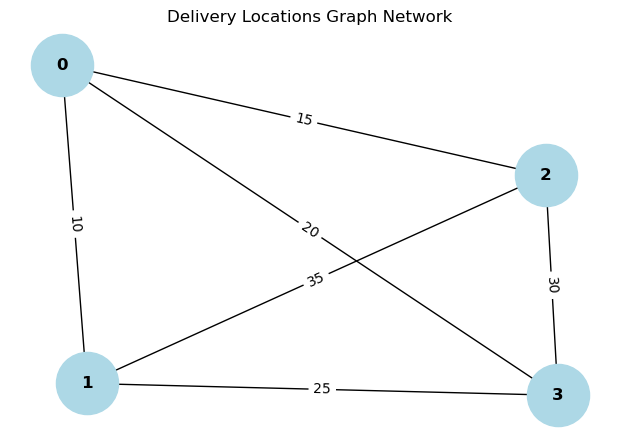

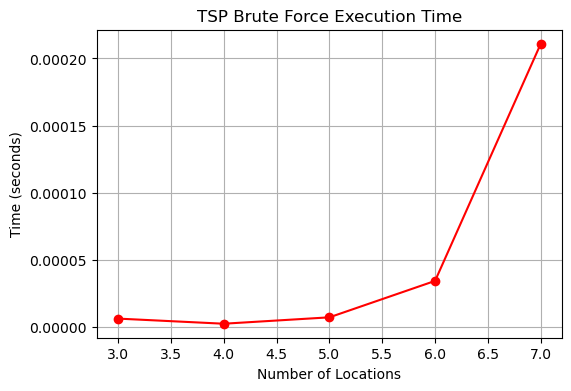

In [7]:
# --- 6. Profiling and Visualization ---

# Plotting the Graph Map
G = nx.Graph()
for i in range(num_locations):
    for j in range(i+1, num_locations):
        if graph_matrix[i][j] != 0:
            G.add_edge(i, j, weight=graph_matrix[i][j])

pos = nx.spring_layout(G)
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Delivery Locations Graph Network")
plt.show()

# Profiling TSP Scalability
sizes = [3, 4, 5, 6, 7]
times = []
for size in sizes:
    test_graph = [[10 if i != j else 0 for j in range(size)] for i in range(size)]
    start = time.time()
    tsp_brute_force(test_graph)
    times.append(time.time() - start)

plt.figure(figsize=(6, 4))
plt.plot(sizes, times, marker='o', color='red')
plt.title("TSP Brute Force Execution Time")
plt.xlabel("Number of Locations")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()

## 5.6 Reflection & Discussion

* **Optimization vs Realism:** The optimal TSP route focuses solely on distance minimization. [cite_start]In reality, it often clashes with strict delivery windows, meaning the absolute shortest physical route might cause late deliveries[cite: 300].
* **Algorithm Trade-offs:** The Greedy parcel selection was by far the fastest (O(N log N) due to sorting). [cite_start]TSP (Brute Force) was the slowest with extreme scalability issues due to its O(N!) factorial complexity[cite: 302].
* **NP-hard Challenge:** As shown in the profiling plot, TSP becomes computationally infeasible around 10-12 locations. [cite_start]Beyond this, heuristic approaches like Genetic Algorithms or Nearest Neighbor are strictly required[cite: 304].
* **Visualization Insight:** The NetworkX route graph made it incredibly easy to visually verify the shortest paths and MST edges against the raw matrix data. [cite_start]The timing plot clearly illustrated the dangerous exponential spike of NP-hard problems[cite: 305].
* [cite_start]**Feature Suggestion:** Adding traffic/time-of-day multipliers to edge weights, or incorporating multi-vehicle routing (VRP), would vastly improve the model's realistic applicability[cite: 307].